# Linear Regression Project Part 2 : Dealing with missing/null values

In [7]:
# Importing the libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv(r"D:\Python\Linear_Reg_Project_data\Ames_outliers_removed.csv")

In [9]:
df.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


### Dropping PID column as it does not make sense for machine learning

In [10]:
df = df.drop('PID', axis = 1)

In [11]:
# Finding out the null values
pd.set_option('display.max_rows', None)
df.isnull().sum().sort_values(ascending = False)

Pool QC            2917
Misc Feature       2824
Alley              2732
Fence              2358
Mas Vnr Type       1775
Fireplace Qu       1422
Lot Frontage        490
Garage Cond         159
Garage Yr Blt       159
Garage Finish       159
Garage Qual         159
Garage Type         157
Bsmt Exposure        83
BsmtFin Type 2       81
BsmtFin Type 1       80
Bsmt Cond            80
Bsmt Qual            80
Mas Vnr Area         23
Bsmt Full Bath        2
Bsmt Half Bath        2
Bsmt Unf SF           1
Garage Cars           1
Electrical            1
Total Bsmt SF         1
BsmtFin SF 1          1
Garage Area           1
BsmtFin SF 2          1
Paved Drive           0
Sale Condition        0
Half Bath             0
Bedroom AbvGr         0
Kitchen AbvGr         0
Kitchen Qual          0
TotRms AbvGrd         0
Functional            0
Fireplaces            0
Sale Type             0
Yr Sold               0
Mo Sold               0
Misc Val              0
Pool Area             0
Screen Porch    

### Finding out the percentage of missing values per column

In [12]:
100 * (df.isnull().sum() / len(df)).sort_values(ascending = False)

Pool QC            99.556314
Misc Feature       96.382253
Alley              93.242321
Fence              80.477816
Mas Vnr Type       60.580205
Fireplace Qu       48.532423
Lot Frontage       16.723549
Garage Cond         5.426621
Garage Yr Blt       5.426621
Garage Finish       5.426621
Garage Qual         5.426621
Garage Type         5.358362
Bsmt Exposure       2.832765
BsmtFin Type 2      2.764505
BsmtFin Type 1      2.730375
Bsmt Cond           2.730375
Bsmt Qual           2.730375
Mas Vnr Area        0.784983
Bsmt Full Bath      0.068259
Bsmt Half Bath      0.068259
Bsmt Unf SF         0.034130
Garage Cars         0.034130
Electrical          0.034130
Total Bsmt SF       0.034130
BsmtFin SF 1        0.034130
Garage Area         0.034130
BsmtFin SF 2        0.034130
Paved Drive         0.000000
Sale Condition      0.000000
Half Bath           0.000000
Bedroom AbvGr       0.000000
Kitchen AbvGr       0.000000
Kitchen Qual        0.000000
TotRms AbvGrd       0.000000
Functional    

In [13]:
# Defining a function for this
def percent_missing(df):
    percent_nan = (df.isnull().sum() / len(df)) * 100
    percent_nan = percent_nan[percent_nan > 0].sort_values()

    return percent_nan

In [14]:
percent_nan = percent_missing(df)

In [15]:
percent_nan

Electrical         0.034130
Garage Cars        0.034130
BsmtFin SF 1       0.034130
Garage Area        0.034130
BsmtFin SF 2       0.034130
Bsmt Unf SF        0.034130
Total Bsmt SF      0.034130
Bsmt Half Bath     0.068259
Bsmt Full Bath     0.068259
Mas Vnr Area       0.784983
Bsmt Qual          2.730375
Bsmt Cond          2.730375
BsmtFin Type 1     2.730375
BsmtFin Type 2     2.764505
Bsmt Exposure      2.832765
Garage Type        5.358362
Garage Qual        5.426621
Garage Cond        5.426621
Garage Yr Blt      5.426621
Garage Finish      5.426621
Lot Frontage      16.723549
Fireplace Qu      48.532423
Mas Vnr Type      60.580205
Fence             80.477816
Alley             93.242321
Misc Feature      96.382253
Pool QC           99.556314
dtype: float64

## Creating a barplot to visualize the missing values

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26],
 [Text(0, 0, 'Electrical'),
  Text(1, 0, 'Garage Cars'),
  Text(2, 0, 'BsmtFin SF 1'),
  Text(3, 0, 'Garage Area'),
  Text(4, 0, 'BsmtFin SF 2'),
  Text(5, 0, 'Bsmt Unf SF'),
  Text(6, 0, 'Total Bsmt SF'),
  Text(7, 0, 'Bsmt Half Bath'),
  Text(8, 0, 'Bsmt Full Bath'),
  Text(9, 0, 'Mas Vnr Area'),
  Text(10, 0, 'Bsmt Qual'),
  Text(11, 0, 'Bsmt Cond'),
  Text(12, 0, 'BsmtFin Type 1'),
  Text(13, 0, 'BsmtFin Type 2'),
  Text(14, 0, 'Bsmt Exposure'),
  Text(15, 0, 'Garage Type'),
  Text(16, 0, 'Garage Qual'),
  Text(17, 0, 'Garage Cond'),
  Text(18, 0, 'Garage Yr Blt'),
  Text(19, 0, 'Garage Finish'),
  Text(20, 0, 'Lot Frontage'),
  Text(21, 0, 'Fireplace Qu'),
  Text(22, 0, 'Mas Vnr Type'),
  Text(23, 0, 'Fence'),
  Text(24, 0, 'Alley'),
  Text(25, 0, 'Misc Feature'),
  Text(26, 0, 'Pool QC')])

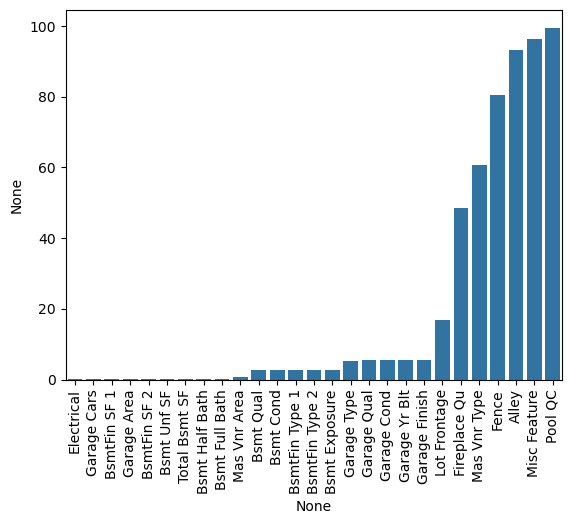

In [16]:
sns.barplot(x = percent_nan.index, y = percent_nan)
# we will rotate the x text values to veritical using below
plt.xticks(rotation = 90)

### Dealing with the columns with less than 1% null values first

In [17]:
percent_nan[percent_nan < 1]

Electrical        0.034130
Garage Cars       0.034130
BsmtFin SF 1      0.034130
Garage Area       0.034130
BsmtFin SF 2      0.034130
Bsmt Unf SF       0.034130
Total Bsmt SF     0.034130
Bsmt Half Bath    0.068259
Bsmt Full Bath    0.068259
Mas Vnr Area      0.784983
dtype: float64

In [18]:
# Finding out the rows that are missing here
df[df['Electrical'].isnull()]
# Looks like there is only 1 row that is missing

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1577,80,RL,73.0,9735,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,167500


In [19]:
df[df['Bsmt Half Bath'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000
1497,20,RL,123.0,47007,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,284700


### Dropping the rows where it's only 1 row

In [20]:
df = df.dropna(axis = 0, subset = ['Electrical', 'Garage Cars'])

In [21]:
percent_nan = percent_missing(df)
percent_nan[percent_nan < 1]

Bsmt Unf SF       0.034153
Total Bsmt SF     0.034153
BsmtFin SF 2      0.034153
BsmtFin SF 1      0.034153
Bsmt Full Bath    0.068306
Bsmt Half Bath    0.068306
Mas Vnr Area      0.785519
dtype: float64

Looks like a lot more null values were removed when we removed just 1 row. This means that they were just bad rows

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, 'Bsmt Unf SF'),
  Text(1, 0, 'Total Bsmt SF'),
  Text(2, 0, 'BsmtFin SF 2'),
  Text(3, 0, 'BsmtFin SF 1'),
  Text(4, 0, 'Bsmt Full Bath'),
  Text(5, 0, 'Bsmt Half Bath'),
  Text(6, 0, 'Mas Vnr Area'),
  Text(7, 0, 'Bsmt Qual'),
  Text(8, 0, 'Bsmt Cond'),
  Text(9, 0, 'BsmtFin Type 1'),
  Text(10, 0, 'BsmtFin Type 2'),
  Text(11, 0, 'Bsmt Exposure'),
  Text(12, 0, 'Garage Type'),
  Text(13, 0, 'Garage Yr Blt'),
  Text(14, 0, 'Garage Qual'),
  Text(15, 0, 'Garage Finish'),
  Text(16, 0, 'Garage Cond'),
  Text(17, 0, 'Lot Frontage'),
  Text(18, 0, 'Fireplace Qu'),
  Text(19, 0, 'Mas Vnr Type'),
  Text(20, 0, 'Fence'),
  Text(21, 0, 'Alley'),
  Text(22, 0, 'Misc Feature'),
  Text(23, 0, 'Pool QC')])

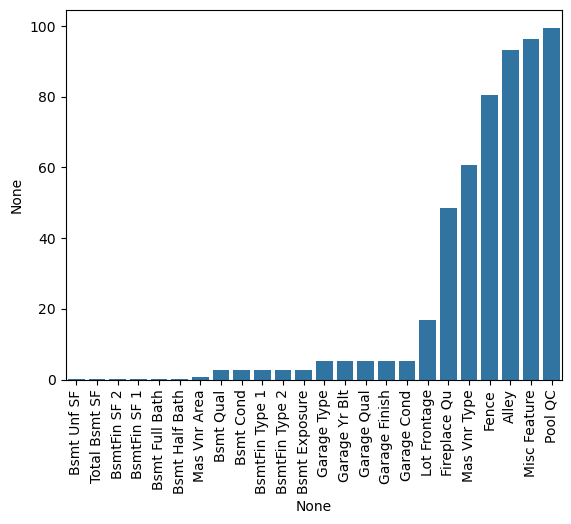

In [22]:
sns.barplot(x = percent_nan.index, y = percent_nan)
# we will rotate the x text values to veritical using below
plt.xticks(rotation = 90)

### Looks like the remaining ones below 1% are values with Basement. They could be those houses without any basement at all

In [23]:
df[df['Bsmt Half Bath'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000
1497,20,RL,123.0,47007,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,284700


In [24]:
df[df['Bsmt Unf SF'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000


In [25]:
df[df['Bsmt Full Bath'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000
1497,20,RL,123.0,47007,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,284700


### 1341 is repeated across all, looks like it does not have a basement as we thought before

### We will not drop them because they are not bad rows but rather just houses without basement and I believe these are equally important for our data. We will replace them with 0

In [26]:
# Dealing with Basement Numeric columns -- Filling null values with 0
bsmt_num_cols = ['BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF','Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath']

# Filling these cols with 0
df[bsmt_num_cols] = df[bsmt_num_cols].fillna(0)

# Dealing with Basement String columns -- Filling them with 'None'
bsmt_str_cols =  ['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2']

# Filling these columns with None
df[bsmt_str_cols] = df[bsmt_str_cols].fillna('None')

In [27]:
# If the above worked, it will give the result as 0
df[df['Bsmt Unf SF'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice


## Let's find out what other columns have less than 1% Missing values

In [28]:
percent_nan = percent_missing(df)
percent_nan[percent_nan < 1]

Mas Vnr Area    0.785519
dtype: float64

### Mas Vnr Area is the column we will now deal with

In [29]:
# Dealing with VNR area - as its numeric, we will just make it 0
df['Mas Vnr Area'] = df['Mas Vnr Area'].fillna(0)

In [30]:
percent_nan = percent_missing(df)
percent_nan[percent_nan < 1]

Series([], dtype: float64)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Garage Type'),
  Text(1, 0, 'Garage Yr Blt'),
  Text(2, 0, 'Garage Finish'),
  Text(3, 0, 'Garage Qual'),
  Text(4, 0, 'Garage Cond'),
  Text(5, 0, 'Lot Frontage'),
  Text(6, 0, 'Fireplace Qu'),
  Text(7, 0, 'Mas Vnr Type'),
  Text(8, 0, 'Fence'),
  Text(9, 0, 'Alley'),
  Text(10, 0, 'Misc Feature'),
  Text(11, 0, 'Pool QC')])

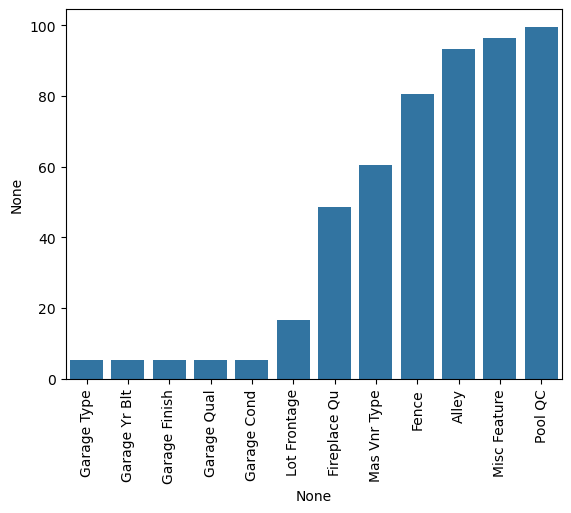

In [31]:
sns.barplot(x = percent_nan.index, y = percent_nan)
# we will rotate the x text values to veritical using below
plt.xticks(rotation = 90)

---

## Now it's time to deal with the Garage columns

Same as above, These are the houses with no Garage and hence have null values, we will deal with them the same way we dealt with Basement

In [32]:
# Splitting the string columns
gar_str_cols = ['Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond']

In [33]:
# Filling them with None values
df[gar_str_cols] = df[gar_str_cols].fillna('None')

In [34]:
# Filling the numeric column with 0
df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(0)

### Let's see the remaining columns now

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Lot Frontage'),
  Text(1, 0, 'Fireplace Qu'),
  Text(2, 0, 'Mas Vnr Type'),
  Text(3, 0, 'Fence'),
  Text(4, 0, 'Alley'),
  Text(5, 0, 'Misc Feature'),
  Text(6, 0, 'Pool QC')])

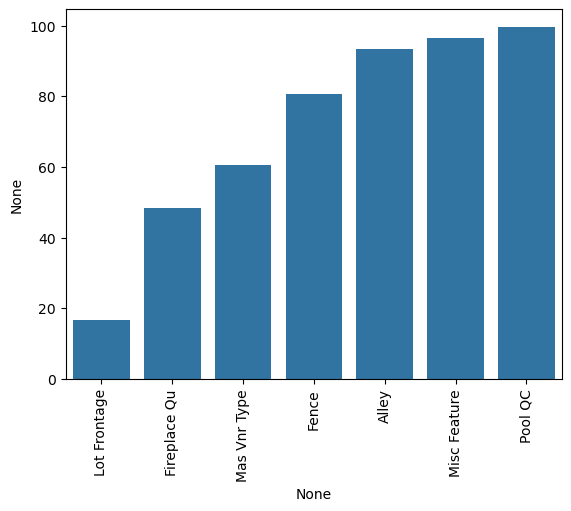

In [35]:
percent_nan = percent_missing(df)
sns.barplot(x = percent_nan.index, y = percent_nan)
# we will rotate the x text values to veritical using below
plt.xticks(rotation = 90)

In [36]:
# Mas Vnr type was not dealt with before - let's fill that with None and remove that from the chart
df["Mas Vnr Type"] = df["Mas Vnr Type"].fillna("None")

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Lot Frontage'),
  Text(1, 0, 'Fireplace Qu'),
  Text(2, 0, 'Fence'),
  Text(3, 0, 'Alley'),
  Text(4, 0, 'Misc Feature'),
  Text(5, 0, 'Pool QC')])

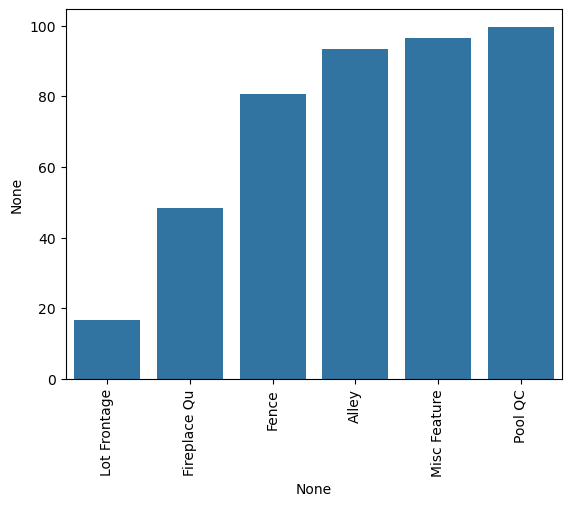

In [37]:
percent_nan = percent_missing(df)
sns.barplot(x = percent_nan.index, y = percent_nan)
# we will rotate the x text values to veritical using below
plt.xticks(rotation = 90)

## Too many missing values for pool, misc, and alley, we will drop them

In [38]:
# We will drop them because there are over 80% missing values, and as per the domain knowledge here, they are not that useful for our model
df = df.drop(['Pool QC', 'Misc Feature', 'Alley', 'Fence'], axis = 1)

([0, 1], [Text(0, 0, 'Lot Frontage'), Text(1, 0, 'Fireplace Qu')])

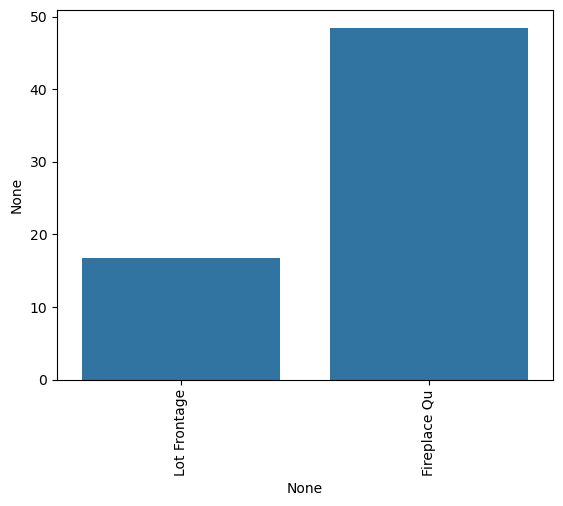

In [39]:
percent_nan = percent_missing(df)
sns.barplot(x = percent_nan.index, y = percent_nan)
# we will rotate the x text values to veritical using below
plt.xticks(rotation = 90)

In [40]:
# Checking what kind of values we have for fireplace
df['Fireplace Qu'].value_counts()

Fireplace Qu
Gd    744
TA    600
Fa     75
Po     46
Ex     43
Name: count, dtype: int64

In [41]:
# As these are string values, we will just replace them with None
df['Fireplace Qu'] = df['Fireplace Qu'].fillna('None')

([0], [Text(0, 0, 'Lot Frontage')])

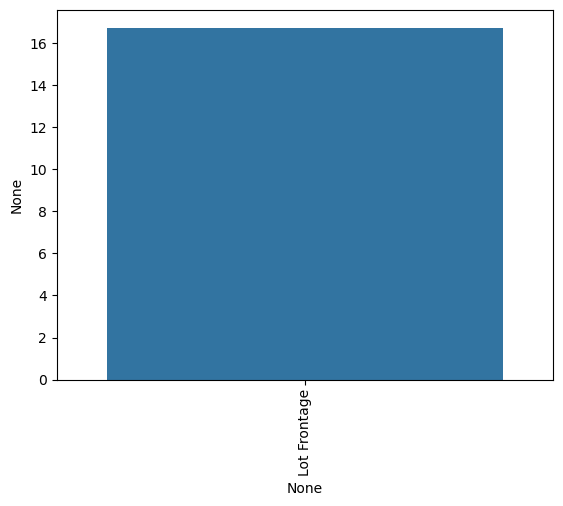

In [42]:
percent_nan = percent_missing(df)
sns.barplot(x = percent_nan.index, y = percent_nan)
# we will rotate the x text values to veritical using below
plt.xticks(rotation = 90)

In [43]:
df['Lot Frontage'].head(20)

0     141.0
1      80.0
2      81.0
3      93.0
4      74.0
5      78.0
6      41.0
7      43.0
8      39.0
9      60.0
10     75.0
11      NaN
12     63.0
13     85.0
14      NaN
15     47.0
16    152.0
17     88.0
18    140.0
19     85.0
Name: Lot Frontage, dtype: float64

### In the text document, we have seen that lot frontage is the linear feet of the street connected to the property and it is very closely related to the neighbourhood column

<Axes: xlabel='Lot Frontage', ylabel='Neighborhood'>

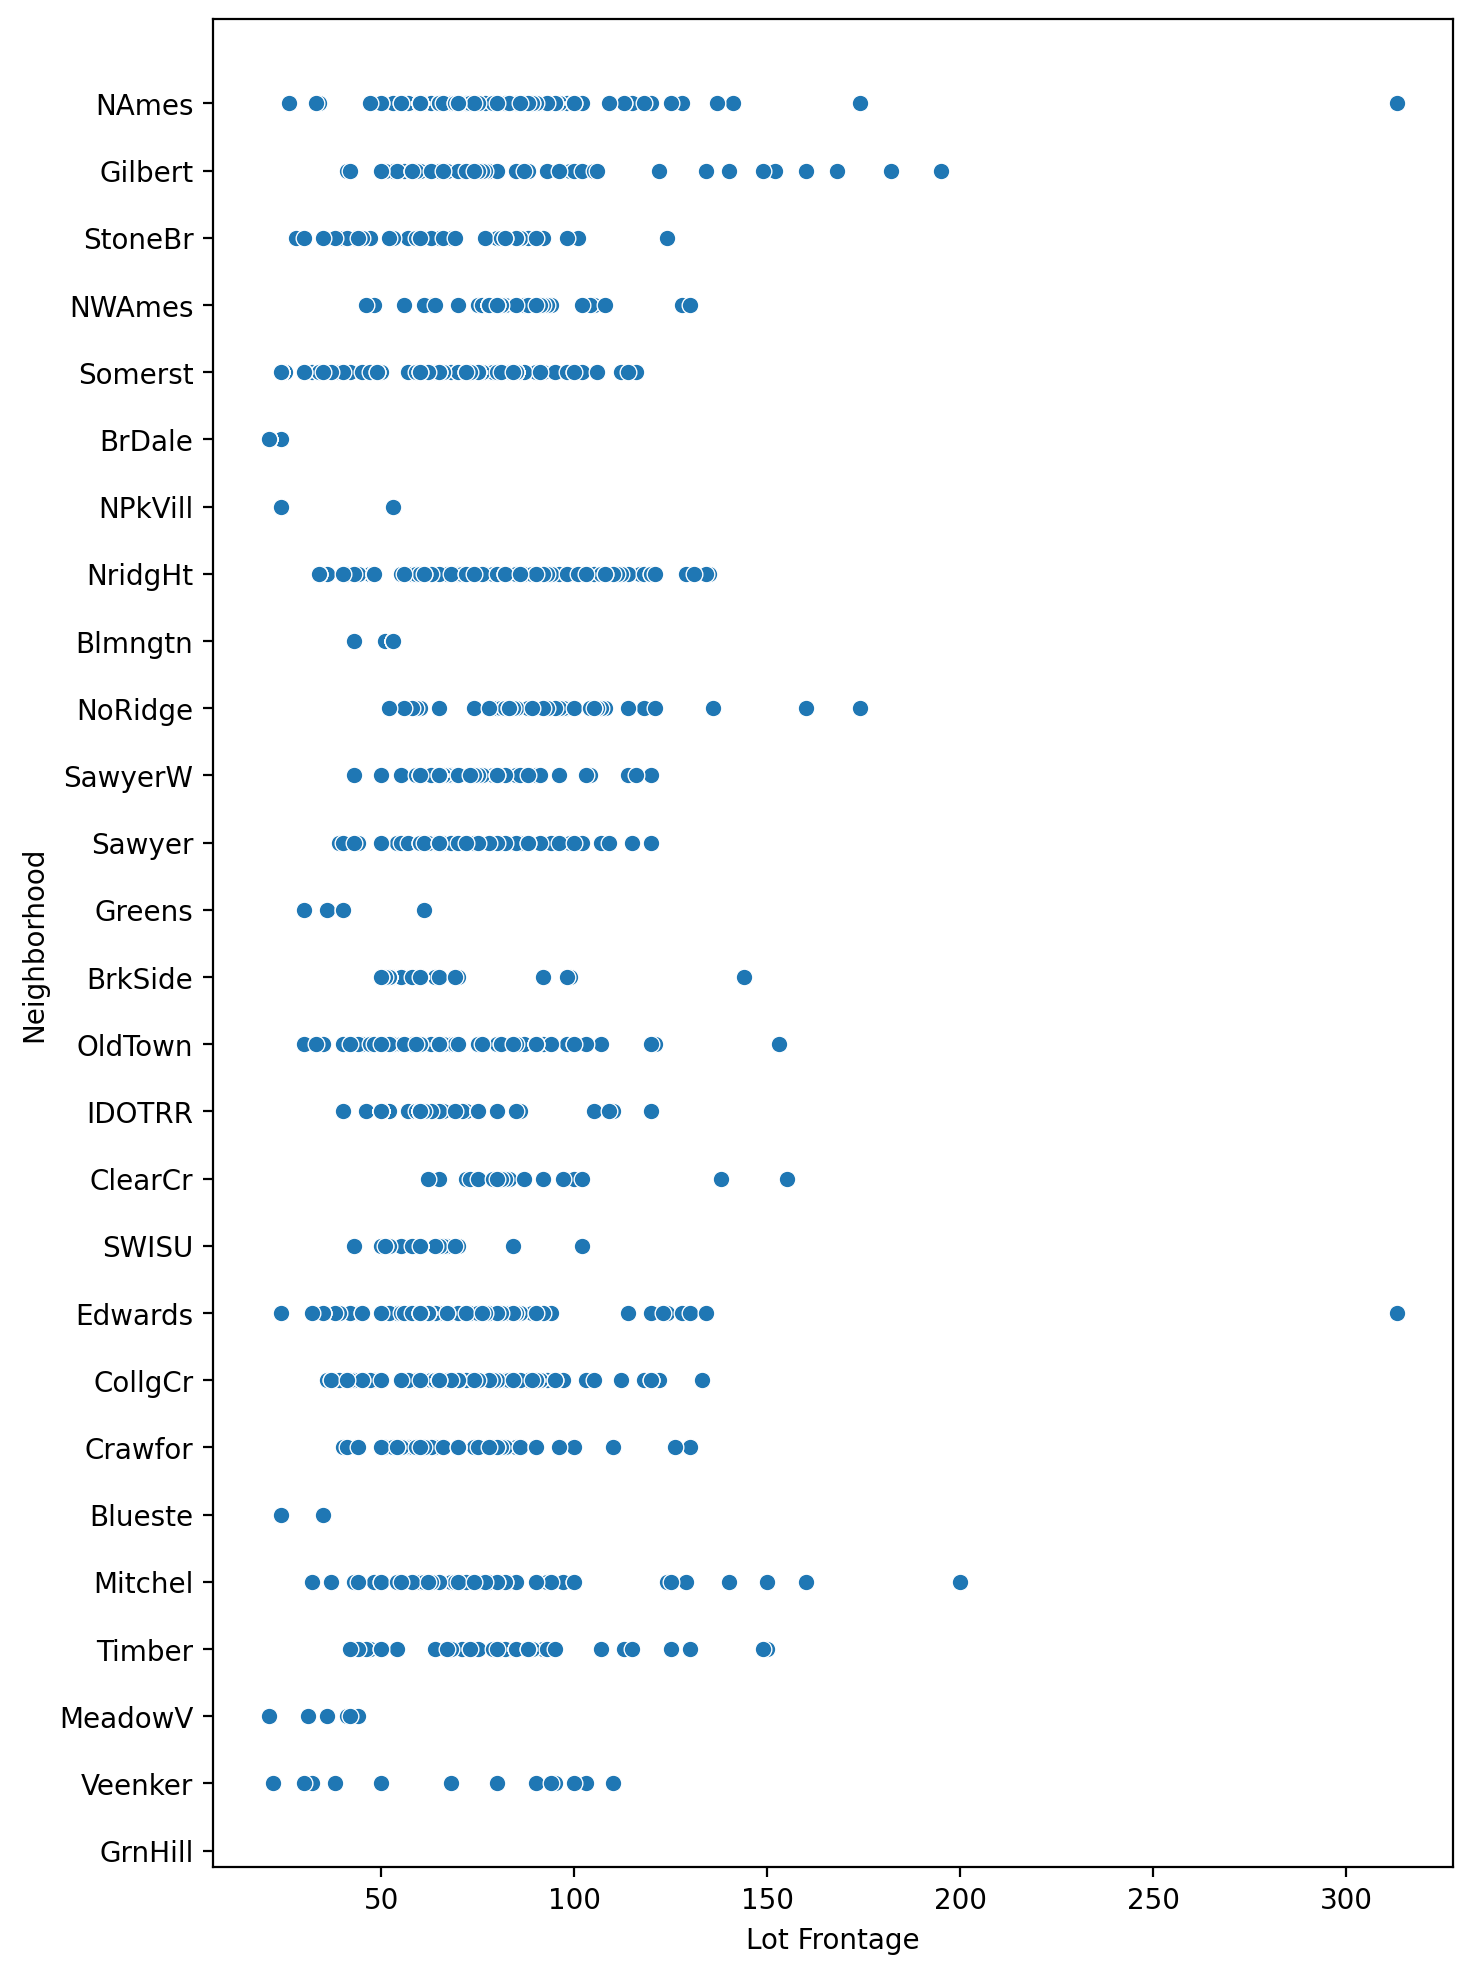

In [44]:
# The points are focused on one particular range together which tells us that lot frontage and neighborhood is connected
plt.figure(figsize = (8, 12), dpi = 200)
sns.scatterplot(x = 'Lot Frontage', y = 'Neighborhood', data = df)

In [45]:
# Calculating group by
df.groupby('Neighborhood')['Lot Frontage'].mean()

Neighborhood
Blmngtn    46.900000
Blueste    27.300000
BrDale     21.500000
BrkSide    55.789474
ClearCr    88.150000
CollgCr    71.336364
Crawfor    69.951807
Edwards    66.910112
Gilbert    74.207207
Greens     41.000000
GrnHill          NaN
IDOTRR     62.383721
Landmrk          NaN
MeadowV    25.606061
Mitchel    75.144444
NAmes      75.210667
NPkVill    28.142857
NWAmes     81.517647
NoRidge    91.629630
NridgHt    84.184049
OldTown    61.777293
SWISU      59.068182
Sawyer     74.551020
SawyerW    70.669811
Somerst    64.549383
StoneBr    62.173913
Timber     81.303571
Veenker    72.000000
Name: Lot Frontage, dtype: float64

In [46]:
# Inserting null values with mean
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x : x.fillna(x.mean()))

([0], [Text(0, 0, 'Lot Frontage')])

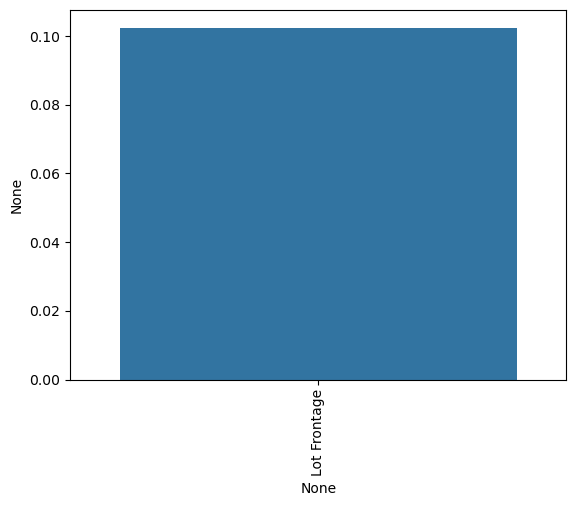

In [47]:
percent_nan = percent_missing(df)
sns.barplot(x = percent_nan.index, y = percent_nan)
# we will rotate the x text values to veritical using below
plt.xticks(rotation = 90)

In [48]:
# Looks like there are still some null values
df[df['Lot Frontage'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2256,120,RM,NaN,9763,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2007,WD,Normal,330000
2788,160,RH,NaN,3612,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,6,2006,WD,Normal,137000
2892,120,RM,NaN,8239,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,11,2006,WD,Normal,230000


In [49]:
# As they are only 3 rows, we can fill them with 0
df['Lot Frontage'] = df['Lot Frontage'].fillna(0)

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

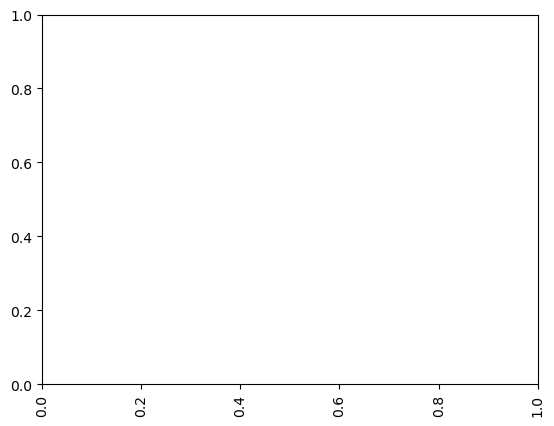

In [50]:
percent_nan = percent_missing(df)
sns.barplot(x = percent_nan.index, y = percent_nan)
# we will rotate the x text values to veritical using below
plt.xticks(rotation = 90)

# All missing values are GONEEEEEE

In [51]:
pd.set_option('display.max_rows', None)
df.isnull().sum()

MS SubClass        0
MS Zoning          0
Lot Frontage       0
Lot Area           0
Street             0
Lot Shape          0
Land Contour       0
Utilities          0
Lot Config         0
Land Slope         0
Neighborhood       0
Condition 1        0
Condition 2        0
Bldg Type          0
House Style        0
Overall Qual       0
Overall Cond       0
Year Built         0
Year Remod/Add     0
Roof Style         0
Roof Matl          0
Exterior 1st       0
Exterior 2nd       0
Mas Vnr Type       0
Mas Vnr Area       0
Exter Qual         0
Exter Cond         0
Foundation         0
Bsmt Qual          0
Bsmt Cond          0
Bsmt Exposure      0
BsmtFin Type 1     0
BsmtFin SF 1       0
BsmtFin Type 2     0
BsmtFin SF 2       0
Bsmt Unf SF        0
Total Bsmt SF      0
Heating            0
Heating QC         0
Central Air        0
Electrical         0
1st Flr SF         0
2nd Flr SF         0
Low Qual Fin SF    0
Gr Liv Area        0
Bsmt Full Bath     0
Bsmt Half Bath     0
Full Bath    

## Adding a checkpoint here, now we have removed both - the outliers and the missing/null values

In [53]:
df.to_csv(r"D:\Python\Linear_Reg_Project_data\Ames_NO_Missing_Data.csv", index = False)